# exp03 - Препроцессинг и Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('../data/credit_risk_dataset.csv')
print(f'Исходный размер: {df_raw.shape}')
df_raw.head()

Исходный размер: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 1. Базовая очистка

In [3]:
df = df_raw.copy()

n_before = len(df)
df = df.drop_duplicates()
print(f'Удалено дубликатов: {n_before - len(df)}')

df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]
print(f'После удаления выбросов: {len(df)} строк')

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median()) # Пропуски после заполнения значений медианой


Удалено дубликатов: 165
После удаления выбросов: 31522 строк


## 2. Новые признаки


In [8]:
# Ежемесячный платёж / месячный доход
df['debt_to_monthly_income'] = df['monthly_payment_approx'] / (df['person_income'] / 12)

# Абсолютная сумма переплаты
df['interest_amount'] = df['loan_amnt'] * df['loan_int_rate'] / 100

# Числовой рейтинг из grade
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade_numeric'] = df['loan_grade'].map(grade_map)

# Владеет жильём или нет
df['is_homeowner'] = df['person_home_ownership'].isin(['OWN', 'MORTGAGE']).astype(int)

# Был дефолт в истории или нет
df['had_default'] = (df['cb_person_default_on_file'] == 'Y').astype(int)

new_features = [
    'debt_to_monthly_income', 'interest_amount', 'loan_grade_numeric',
    'is_homeowner', 'had_default'
]

print(f'Создано новых признаков: {len(new_features)}')
print(f'Итого признаков: {df.shape[1]}')
df[new_features].head()

Создано новых признаков: 5
Итого признаков: 23


,debt_to_monthly_income,interest_amount,loan_grade_numeric,is_homeowner,had_default
1,0.034722,111.40,2,1,0
2,0.190972,707.85,3,1,0
3,0.178117,5330.50,3,0,0
4,0.214461,4994.50,3,0,1
5,0.084175,178.50,1,1,0


## 3. Визуализация новых признаков

### 3.1 Распределение долговой нагрузки по классам

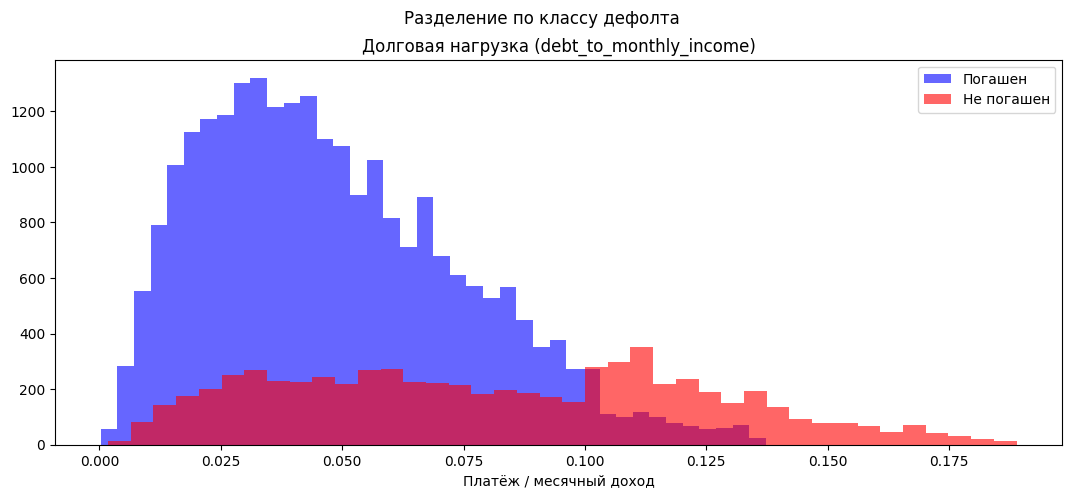

In [13]:
fig, axes = plt.subplots(figsize=(13, 5))

# debt_to_monthly_income
for label, color in [(0, 'blue'), (1, 'red')]:
    subset = df[df['loan_status'] == label]['debt_to_monthly_income']
    subset = subset[subset < subset.quantile(0.99)] 
    axes.hist(subset, bins=40, alpha=0.6, color=color,
                 label='Погашен' if label == 0 else 'Не погашен')
axes.set_title('Долговая нагрузка (debt_to_monthly_income)')
axes.set_xlabel('Платёж / месячный доход')
axes.legend()

plt.suptitle('Разделение по классу дефолта')
plt.show()

### 3.2 Дефолт-рейт по возрастным группам

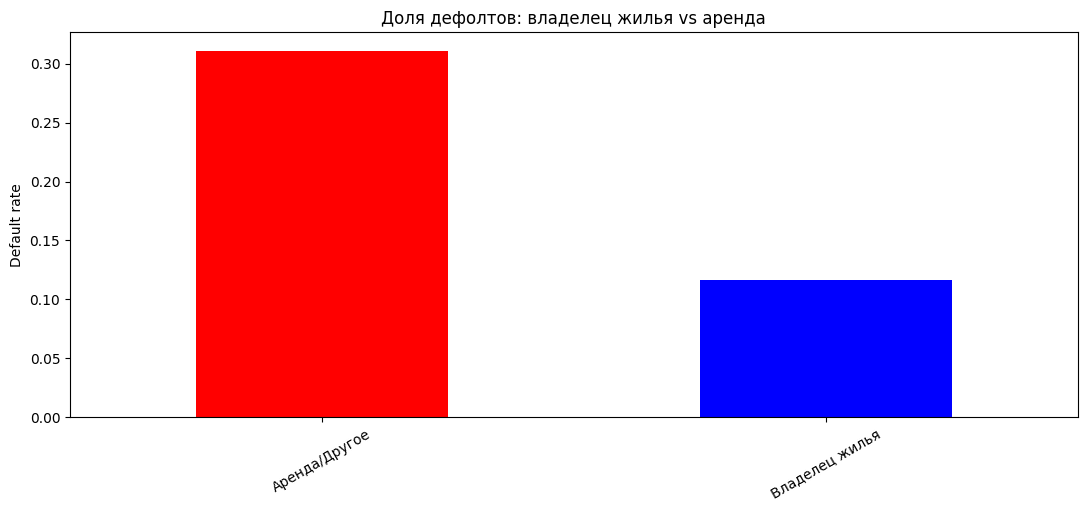

In [19]:
fig, axes = plt.subplots(figsize=(13, 5))

# Дефолт-рейт для владельцев жилья
home_default = df.groupby('is_homeowner')['loan_status'].mean()
home_default.index = ['Аренда/Другое', 'Владелец жилья']
home_default.plot(kind='bar', ax=axes, color=['red', 'blue'])
axes.set_title('Доля дефолтов: владелец жилья vs аренда')
axes.set_ylabel('Default rate')
axes.set_xlabel('')
axes.tick_params(axis='x', rotation=30)
plt.show()

### 3.3 Корреляция новых признаков с loan_status

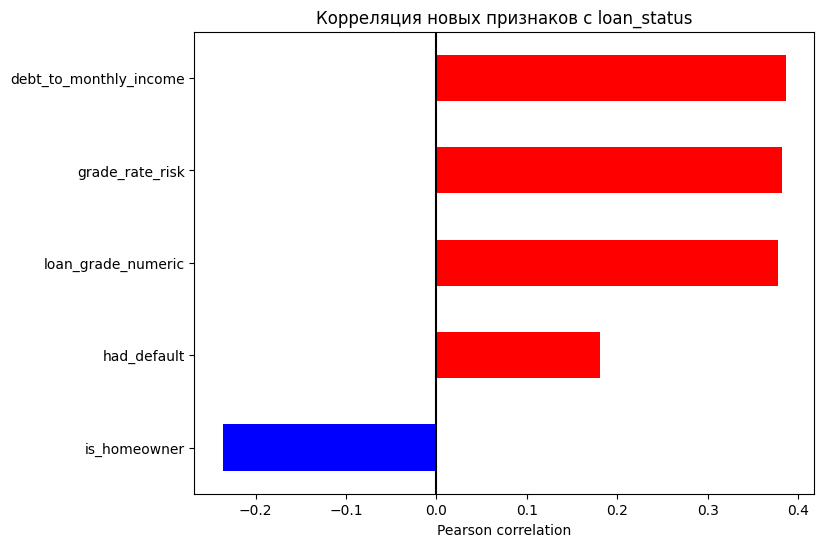

In [20]:
new = ['debt_to_monthly_income', 'loan_grade_numeric', 
               'grade_rate_risk', 'is_homeowner', 'had_default'
]

corr_with_target = df[new + ['loan_status']].corr()['loan_status'].drop('loan_status').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red' if v > 0 else 'blue' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black')
ax.set_title('Корреляция новых признаков с loan_status')
ax.set_xlabel('Pearson correlation')
plt.show()

## 4. Выводы

**Наиболее информативные новые признаки:**
- `grade_rate_risk` — произведение кредитного рейтинга на ставку: сильно разделяет классы
- `loan_grade_numeric` — числовой рейтинг: чем хуже рейтинг, тем выше дефолт-рейт
- `debt_to_monthly_income` — долговая нагрузка: у дефолтников заметно выше